# QuantGAN Evaluation

This notebook demonstrates how to evaluate a trained QuantGAN model.

In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.stats import kurtosis

from quantgan import (
    DataConfig,
    PreprocessConfig,
    DatasetConfig,
    ModelConfig,
    TrainConfig,
)
from quantgan.data import DefeatBetaSource, LambertWPreprocessor
from quantgan.evaluation import PaperEvaluator, Plotter
from quantgan.utils import set_all_seeds, build_and_load_generator, generate_M_paths_raw

print("TensorFlow:", tf.__version__)



2026-02-26 12:50:31.651779: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-26 12:50:31.654549: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-26 12:50:32.082227: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-26 12:50:40.582001: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or

TensorFlow: 2.20.0


## 1. Configuration and Data Loading

In [2]:
# Configuration
data_cfg = DataConfig()
pre_cfg = PreprocessConfig()
ds_cfg = DatasetConfig()
model_cfg = ModelConfig(
    generator_type="pure_tcn",  # Must match trained model
)
train_cfg = TrainConfig()

# Evaluation settings
WEIGHTS_PATH = "./quantgan_outputs_wgangp/bestG_pure_tcn_seed0_epoch180.weights.pkl"
M = 500  # Number of paths to generate
Ttilde = 4000  # Length of generated paths
S_lags = 250  # Lags for ACF/leverage plots
SEED = 0

set_all_seeds(SEED)

In [3]:
# Load real data
src = DefeatBetaSource(data_cfg)
df = src.fetch()
close = df["Close"].dropna()
real_series = src.log_returns_from_close(df)
T_real = len(real_series)

print(f"[DATA] {data_cfg.ticker} T={T_real} "
      f"mean={float(real_series.mean()):.6g} std={float(real_series.std()):.6g} "
      f"kurt={float(kurtosis(real_series, fisher=False, bias=False)):.3f}")

[DATA] Loaded from cache: data/defeatbeta_SPY_2009-05-01_2018-12-31_1d.csv
[DATA] SPY T=2433 mean=0.000429533 std=0.00962302 kurt=6.975


In [4]:
# Fit preprocessor on real data
pre = LambertWPreprocessor(pre_cfg).fit(real_series)
print("[PRE] state:", pre.summary())

[PRE] state: {'use_lambert': True, 'renorm_after_lambert': True, 'r_mean': 0.0004295334295416232, 'r_std': 0.009623020589921769, 'lam_mu': 0.036145429573328836, 'lam_sigma': 0.6655962445571071, 'delta_hat': 0.24627699358959143, 'u_mean': -0.0225337046505423, 'u_std': 0.9997461160580793}


---
## Pure TCN

## 2. Load Trained Model

In [6]:
# Build and load generator
netG = build_and_load_generator(
    model_cfg=model_cfg,
    window_len=ds_cfg.window_len,
    weights_path=WEIGHTS_PATH,
    seed=SEED,
)

print(f"[MODEL] Generator loaded: {model_cfg.generator_type}")
print(f"[MODEL] Parameters: {netG.count_params():,}")

# Generator summaries
print('=== Pure TCN Generator ===')
netG.summary()

[MODEL] Generator loaded: pure_tcn
[MODEL] Parameters: 210,161
=== Pure TCN Generator ===


Model: "G_PURE_TCN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, None, 3)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_block_7         │ (None, None, 80)  │      7,280 │ input_layer_1[0]… │
│ (TCNBlock)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_block_8         │ (None, None, 80)  │     26,240 │ tcn_block_7[0][0] │
│ (TCNBlock)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_block_9         │ (None, None, 80)  │     26,240 │ tcn_block_8[0][0] │
│ (TCNBlock)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_block_10        │ (None, None, 80)  │     26,240 │ tcn_block_9[0][0] │
│ (TCNBlock)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_block_11        │ (None, None, 80)  │     26,240 │ tcn_block_10[0][… │
│ (TCNBlock)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_block_12        │ (None, None, 80)  │     26,240 │ tcn_block_11[0][… │
│ (TCNBlock)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_block_13        │ (None, None, 80)  │     26,240 │ tcn_block_12[0][… │
│ (TCNBlock)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_24 (Conv1D)  │ (None, None, 80)  │      6,480 │ tcn_block_7[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_27 (Conv1D)  │ (None, None, 80)  │      6,480 │ tcn_block_8[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_30 (Conv1D)  │ (None, None, 80)  │      6,480 │ tcn_block_9[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_33 (Conv1D)  │ (None, None, 80)  │      6,480 │ tcn_block_10[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_36 (Conv1D)  │ (None, None, 80)  │      6,480 │ tcn_block_11[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_39 (Conv1D)  │ (None, None, 80)  │      6,480 │ tcn_block_12[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_42 (Conv1D)  │ (None, None, 80)  │      6,480 │ tcn_block_13[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, None, 80)  │          0 │ conv1d_24[0][0],  │
│                     │                   │            │ conv1d_27[0][0],  │
│                     │                   │            │ conv1d_30[0][0],  │
│                     │                   │            │ conv1d_33[0][0],  │
│                     │                   │            │ conv1d_36[0][0],  │
│                     │                   │            │ conv1d_39[0][0],  │
│                     │                   │            │ conv1d_42[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_43 (Conv1D)  │ (None, None, 1)   │         81 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ soft_clip (Lambda)  │ (None, None, 1)   │          0 │ conv1d_43[0][0] 

 Total params: 210,161 (820.94 KB)

 Trainable params: 210,161 (820.94 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Generate Synthetic Paths

In [7]:
# Generate M paths of length Ttilde
fake_paths = generate_M_paths_raw(
    netG=netG,
    preproc=pre,
    M=M,
    Ttilde=Ttilde,
    window_len=ds_cfg.window_len,
    z_dim=model_cfg.z_dim,
    batch=50,
    seed=SEED,
)

print(f"[GENERATED] shape={fake_paths.shape}")
print(f"[GENERATED] mean={float(fake_paths.mean()):.6g} "
      f"std={float(fake_paths.std()):.6g} "
      f"kurt={float(kurtosis(fake_paths.reshape(-1), fisher=False, bias=False)):.3f}")

[GENERATED] shape=(500, 4000)
[GENERATED] mean=0.000426096 std=0.00896121 kurt=8.308


## 5. Evaluate with Paper Metrics

In [8]:
# Compute paper score
evaluator = PaperEvaluator(
    real_series=real_series,
    preproc=pre,
    train_cfg=train_cfg,
    dy_base_t=len(real_series),
)

paper_score, parts = evaluator.paper_score(fake_paths)

print(f"\n=== PAPER SCORE: {paper_score:.6g} ===")
print(f"ACF(r):   {parts['acf_x']:.4g}")
print(f"ACF(|r|): {parts['acf_abs']:.4g}")
print(f"ACF(r²):  {parts['acf_sq']:.4g}")
print(f"Leverage: {parts['lev']:.4g}")
print(f"DY sum:   {parts['dy_sum']:.4g}")
print(f"DY by lag: {parts['dy_by_t']}")


=== PAPER SCORE: 0.124142 ===
ACF(r):   0.02266
ACF(|r|): 0.02422
ACF(r²):  0.02254
Leverage: 0.3201
DY sum:   90.82
DY by lag: {1: 18.594909935726104, 5: 16.70630909856274, 20: 20.026896639684796, 100: 35.487548467081474}


## 6. Visualizations

In [9]:
# Create plotter
plotter = Plotter(show=True, save=False)

# For plotting, slice to match real data length
fake_for_plots = fake_paths[:, :T_real]

In [10]:
# --- PDF output directories ---
import os
_DIRS = {
    'pure_tcn': 'pure_tcn_eval_outputs',
    'svnn':     'svnn_eval_outputs',
    'garch':    'garch_outputs',
}
for _d in _DIRS.values():
    os.makedirs(_d, exist_ok=True)
print('Output dirs ready:', list(_DIRS.values()))

Output dirs ready: ['pure_tcn_eval_outputs', 'svnn_eval_outputs', 'garch_outputs']


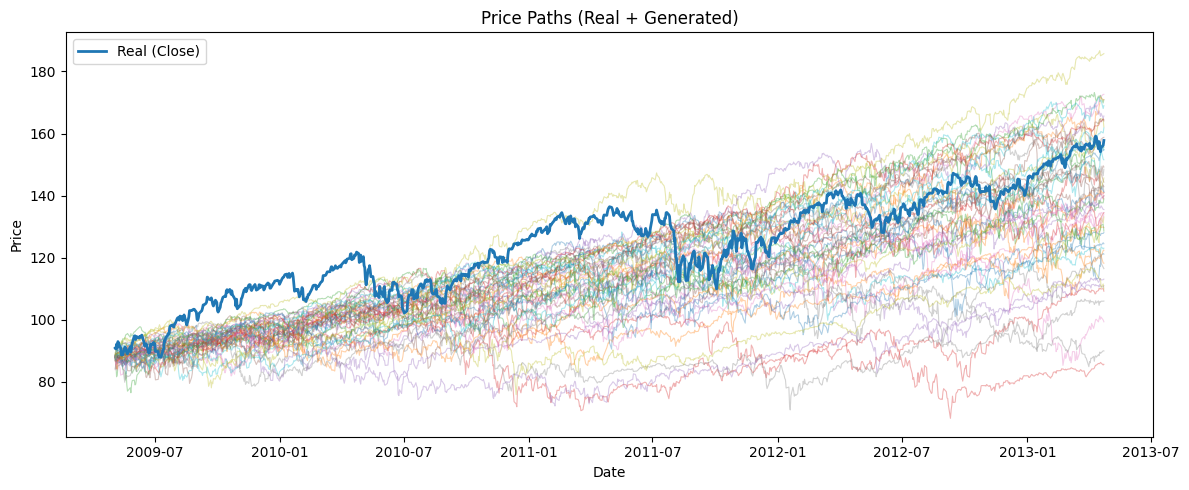

In [11]:
# Plot price paths (1000 days)
N9Y = 1000
plotter.plot_price_paths(
    close_series=close.iloc[:N9Y + 1],
    fake_logret_paths=fake_paths[:, :N9Y],
    n_paths=50,
    title="Price Paths (Real + Generated)",
)


In [12]:
# --- Save: Pure TCN price paths ---
N9Y = 1000
_ps = Plotter(show=False, save=True, out_dir=_DIRS['pure_tcn'])
_ps.plot_price_paths(
    close_series=close.iloc[:N9Y + 1],
    fake_logret_paths=fake_paths[:, :N9Y],
    n_paths=50,
    title='Price Paths (Real + Generated)',
    filename='paths.pdf',
)
print('Saved: pure_tcn/paths.pdf')


Saved: pure_tcn/paths.pdf


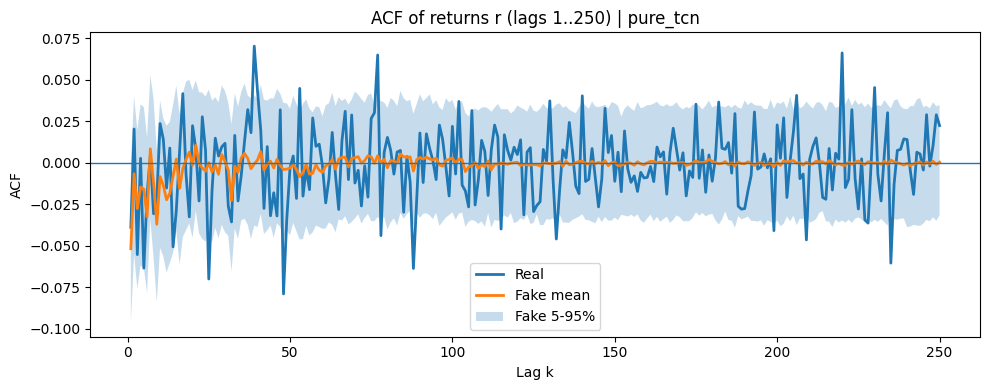

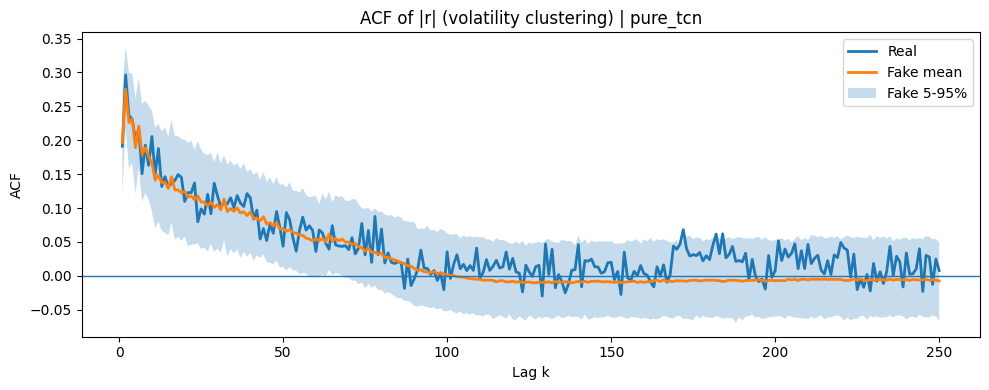

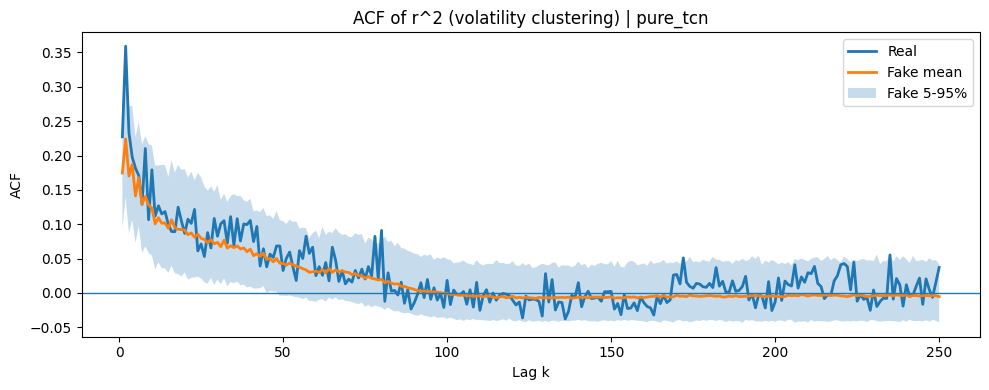

In [13]:
# Plot ACF bundle
plotter.plot_acf_bundle(
    real_r=real_series,
    fake_paths=fake_for_plots,
    S=S_lags,
    title_suffix=f" | {model_cfg.generator_type}",
)

In [14]:
# --- Save: Pure TCN ACF bundle ---
_ps = Plotter(show=False, save=True, out_dir=_DIRS['pure_tcn'])
_ps.plot_acf_bundle(
    real_r=real_series,
    fake_paths=fake_for_plots,
    S=S_lags,
    title_suffix=f' | {model_cfg.generator_type}',
    filename_prefix='acf',
)
print('Saved: pure_tcn/acf_r.pdf, acf_abs.pdf, acf_sq.pdf')

Saved: pure_tcn/acf_r.pdf, acf_abs.pdf, acf_sq.pdf


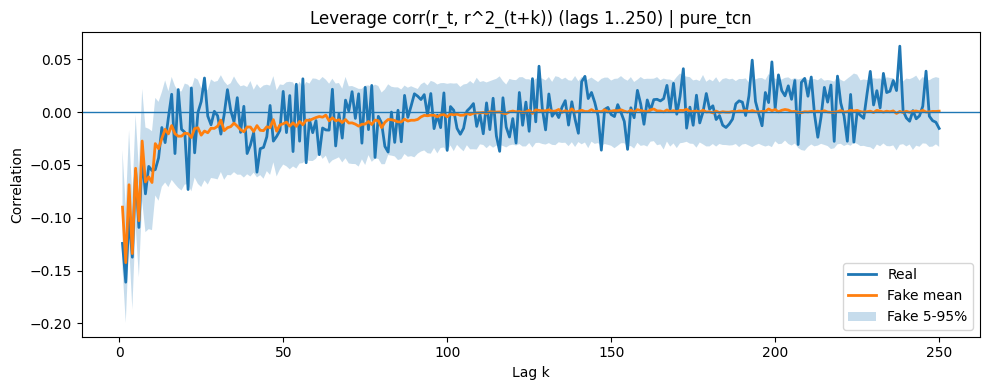

In [15]:
# Plot leverage
plotter.plot_leverage(
    real_r=real_series,
    fake_paths=fake_for_plots,
    S=S_lags,
    title_suffix=f" | {model_cfg.generator_type}",
)

In [16]:
# --- Save: Pure TCN leverage ---
_ps = Plotter(show=False, save=True, out_dir=_DIRS['pure_tcn'])
_ps.plot_leverage(
    real_r=real_series,
    fake_paths=fake_for_plots,
    S=S_lags,
    title_suffix=f' | {model_cfg.generator_type}',
    filename='leverage.pdf',
)
print('Saved: pure_tcn/leverage.pdf')

Saved: pure_tcn/leverage.pdf


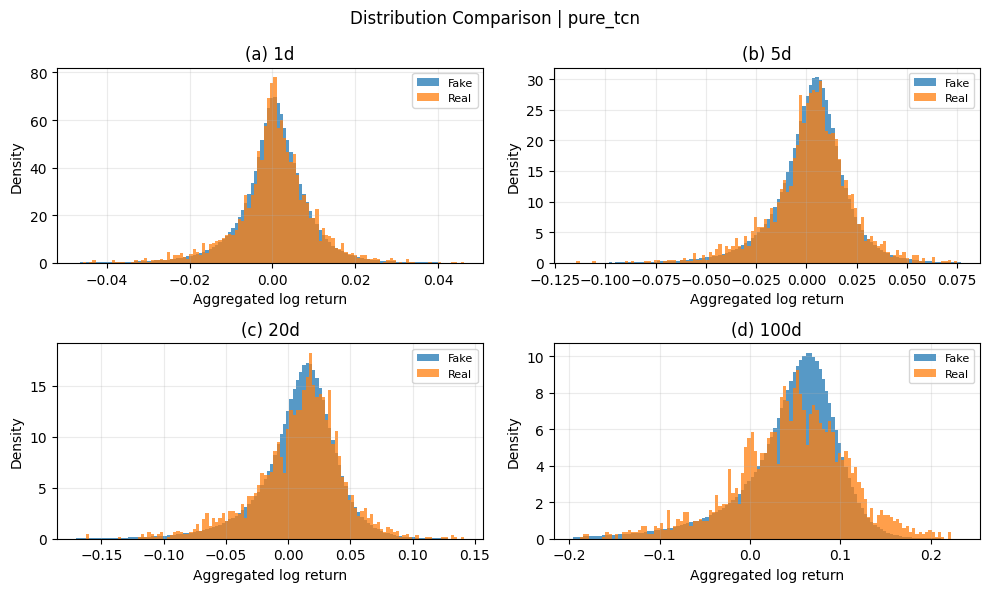

In [17]:
# Plot histogram panel
plotter.plot_hist_panel(
    real_r=real_series,
    fake_paths=fake_for_plots,
    t_lags=(1, 5, 20, 100),
    title=f"Distribution Comparison | {model_cfg.generator_type}",
)

In [18]:
# --- Save: Pure TCN histogram panel ---
_ps = Plotter(show=False, save=True, out_dir=_DIRS['pure_tcn'])
_ps.plot_hist_panel(
    real_r=real_series,
    fake_paths=fake_for_plots,
    t_lags=(1, 5, 20, 100),
    title=f'Distribution Comparison | {model_cfg.generator_type}',
    filename='hist-2x2.pdf',
)
print('Saved: pure_tcn/hist-2x2.pdf')

Saved: pure_tcn/hist-2x2.pdf


---
## SVNN Evaluation

In [19]:
# SVNN configuration
model_cfg_svnn = ModelConfig(
    generator_type="svnn",
    g_ch=60,
    g_ch_hidden=60,
)

WEIGHTS_PATH_SVNN = "./quantgan_outputs_wgangp/bestG_svnn_seed0_epoch220.weights.pkl"

set_all_seeds(SEED)


In [20]:
# Build and load SVNN generator
netG_svnn = build_and_load_generator(
    model_cfg=model_cfg_svnn,
    window_len=ds_cfg.window_len,
    weights_path=WEIGHTS_PATH_SVNN,
    seed=SEED,
)
print(f"[SVNN] Generator loaded: {model_cfg_svnn.generator_type}")
print(f"[SVNN] Parameters: {netG_svnn.count_params():,}")
print('\n=== SVNN Generator ===')
netG_svnn.summary()

[SVNN] Generator loaded: svnn
[SVNN] Parameters: 119,282

=== SVNN Generator ===


Model: "G_SVNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, None, 3)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_shift_for_sigma_… │ (None, None, 3)   │          0 │ input_layer_2[0]… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_block_14        │ (None, None, 60)  │      4,260 │ z_shift_for_sigm… │
│ (TCNBlock)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_block_15        │ (None, None, 60)  │     14,880 │ tcn_block_14[0][… │
│ (TCNBlock)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_block_16        │ (None, None, 60)  │     14,880 │ tcn_block_15[0][… │
│ (TCNBlock)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_block_17        │ (None, None, 60)  │     14,880 │ tcn_block_16[0][… │
│ (TCNBlock)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_block_18        │ (None, None, 60)  │     14,880 │ tcn_block_17[0][… │
│ (TCNBlock)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_block_19        │ (None, None, 60)  │     14,880 │ tcn_block_18[0][… │
│ (TCNBlock)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_block_20        │ (None, None, 60)  │     14,880 │ tcn_block_19[0][… │
│ (TCNBlock)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_46 (Conv1D)  │ (None, None, 60)  │      3,660 │ tcn_block_14[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_49 (Conv1D)  │ (None, None, 60)  │      3,660 │ tcn_block_15[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_52 (Conv1D)  │ (None, None, 60)  │      3,660 │ tcn_block_16[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_55 (Conv1D)  │ (None, None, 60)  │      3,660 │ tcn_block_17[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_58 (Conv1D)  │ (None, None, 60)  │      3,660 │ tcn_block_18[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_61 (Conv1D)  │ (None, None, 60)  │      3,660 │ tcn_block_19[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_64 (Conv1D)  │ (None, None, 60)  │      3,660 │ tcn_block_20[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, None, 60)  │          0 │ conv1d_46[0][0],  │
│                     │                   │            │ conv1d_49[0][0],  │
│                     │                   │            │ conv1d_52[0][0],  │
│                     │                   │            │ conv1d_55[0][0],  │
│                     │                   │            │ conv1d_58[0][0],  │
│                     │                   │            │ conv1d_61[0][0],  │
│                     │                   │            │ conv1d_64[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 119,282 (465.95 KB)

 Trainable params: 119,282 (465.95 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Generate SVNN paths
fake_paths_svnn = generate_M_paths_raw(
    netG=netG_svnn,
    preproc=pre,
    M=M,
    Ttilde=Ttilde,
    window_len=ds_cfg.window_len,
    z_dim=model_cfg_svnn.z_dim,
    batch=50,
    seed=SEED,
)
print(f"[SVNN] shape={fake_paths_svnn.shape}")
print(f"[SVNN] mean={float(fake_paths_svnn.mean()):.6g} std={float(fake_paths_svnn.std()):.6g} "
      f"kurt={float(kurtosis(fake_paths_svnn.reshape(-1), fisher=False, bias=False)):.3f}")


[SVNN] shape=(500, 4000)
[SVNN] mean=0.000410987 std=0.00907149 kurt=7.566


In [22]:
# SVNN paper score
paper_score_svnn, parts_svnn = evaluator.paper_score(fake_paths_svnn)

print(f"\n=== SVNN PAPER SCORE: {paper_score_svnn:.6g} ===")
print(f"ACF(r):   {parts_svnn['acf_x']:.4g}")
print(f"ACF(|r|): {parts_svnn['acf_abs']:.4g}")
print(f"ACF(r²):  {parts_svnn['acf_sq']:.4g}")
print(f"Leverage: {parts_svnn['lev']:.4g}")
print(f"DY sum:   {parts_svnn['dy_sum']:.4g}")
print(f"DY by lag: {parts_svnn['dy_by_t']}")



=== SVNN PAPER SCORE: 0.124926 ===
ACF(r):   0.02283
ACF(|r|): 0.02557
ACF(r²):  0.02572
Leverage: 0.3229
DY sum:   74.11
DY by lag: {1: 18.04766460130407, 5: 14.945921495652776, 20: 17.541514691301913, 100: 23.572746388461127}


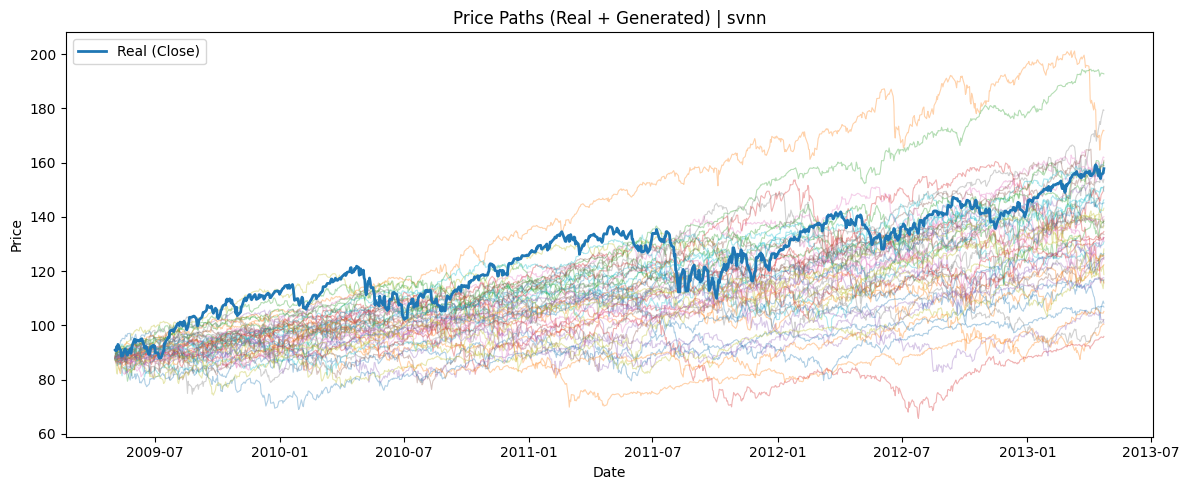

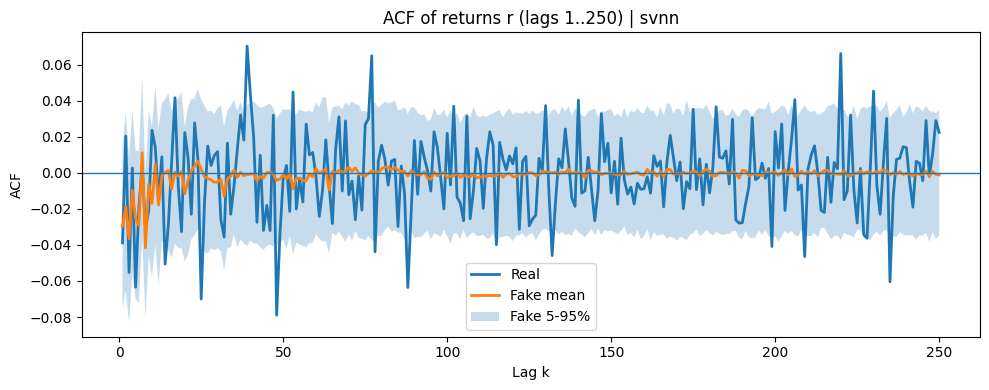

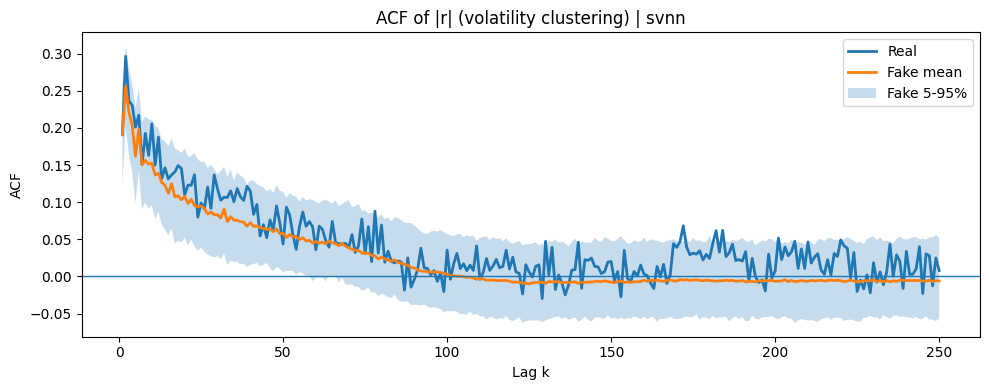

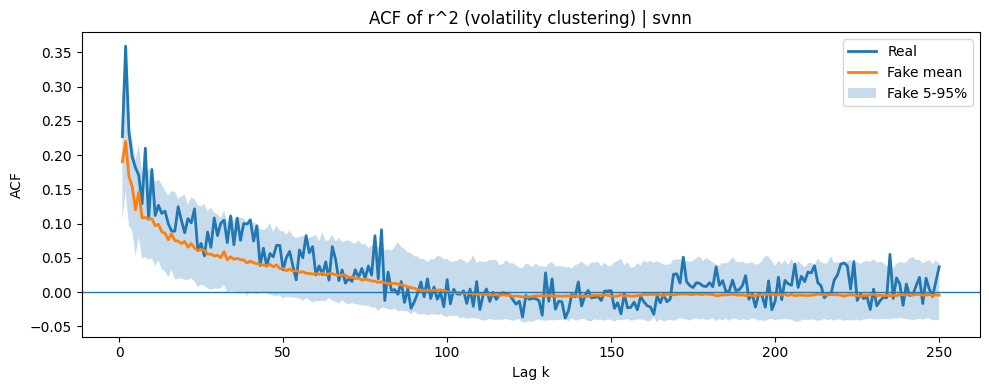

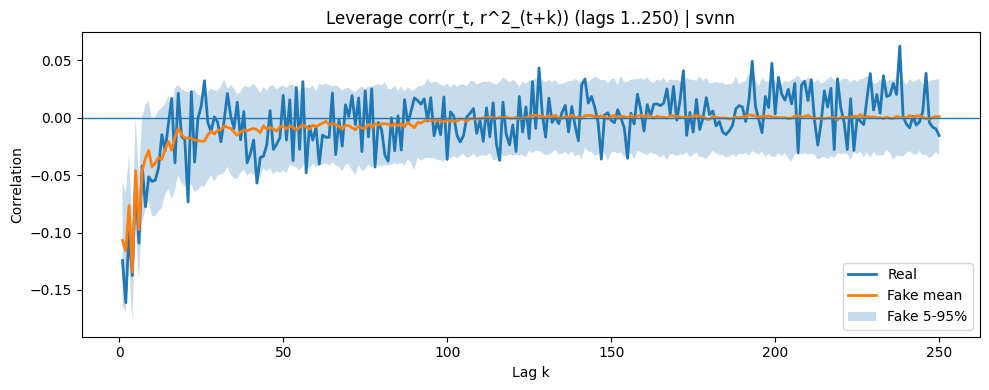

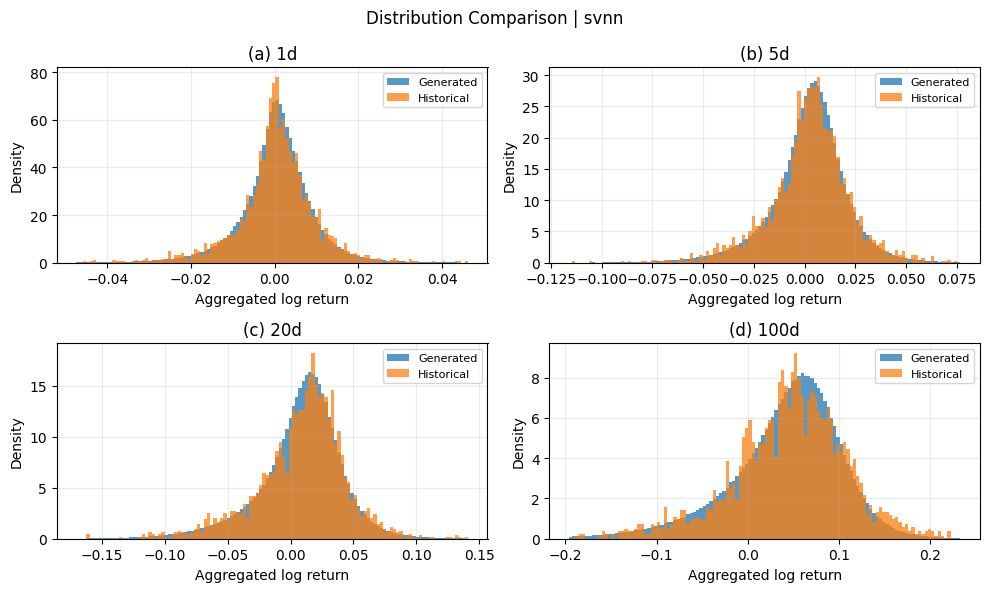

In [23]:
# SVNN plots

N9Y = 1000
plotter.plot_price_paths(
    close_series=close.iloc[:N9Y + 1],
    fake_logret_paths=fake_paths_svnn[:, :N9Y],
    n_paths=50,
    title='Price Paths (Real + Generated) | svnn',
)

fake_for_plots_svnn = fake_paths_svnn[:, :T_real]

plotter.plot_acf_bundle(
    real_r=real_series,
    fake_paths=fake_for_plots_svnn,
    S=S_lags,
    title_suffix=" | svnn",
)
plotter.plot_leverage(
    real_r=real_series,
    fake_paths=fake_for_plots_svnn,
    S=S_lags,
    title_suffix=" | svnn",
)
plotter.plot_hist_panel(
    real_r=real_series,
    fake_paths=fake_for_plots_svnn,
    t_lags=(1, 5, 20, 100),
    title="Distribution Comparison | svnn",
    label_fake="Generated",
    label_real="Historical",
)


In [24]:
# --- Save: SVNN plots ---
N9Y = 1000
_ps = Plotter(show=False, save=True, out_dir=_DIRS['svnn'])
_ps.plot_price_paths(
    close_series=close.iloc[:N9Y + 1],
    fake_logret_paths=fake_paths_svnn[:, :N9Y],
    n_paths=50,
    title='Price Paths (Real + Generated) | svnn',
    filename='paths.pdf',
)
_ps.plot_acf_bundle(
    real_r=real_series,
    fake_paths=fake_for_plots_svnn,
    S=S_lags,
    title_suffix=' | svnn',
    filename_prefix='acf',
)
_ps.plot_leverage(
    real_r=real_series,
    fake_paths=fake_for_plots_svnn,
    S=S_lags,
    title_suffix=' | svnn',
    filename='leverage.pdf',
)
_ps.plot_hist_panel(
    real_r=real_series,
    fake_paths=fake_for_plots_svnn,
    t_lags=(1, 5, 20, 100),
    title='Distribution Comparison | svnn',
    label_fake='Generated',
    label_real='Historical',
    filename='hist-2x2.pdf',
)
print('Saved: svnn_eval_outputs/*.pdf')


Saved: svnn_eval_outputs/*.pdf


---
## GARCH(1,1) Baseline

In [25]:
import math
from scipy.stats import wasserstein_distance
try:
    from arch import arch_model
except ImportError:
    raise ImportError("Install via: pip install arch")


In [26]:
# Fit GARCH(1,1) on real data
_scale = 100.0
_y_fit = _scale * real_series

_am = arch_model(_y_fit, mean="Constant", vol="GARCH", p=1, q=1, dist="normal")
_res = _am.fit(disp="off", update_freq=0)
_params = _res.params

_mu_hat    = float(_params.get("mu", _params.get("Const")))
_omega_hat = float(_params.get("omega"))
_alpha_hat = float(_params.get("alpha[1]"))
_beta_hat  = float(_params.get("beta[1]"))

_mu_fit = _mu_hat / _scale
_omega  = _omega_hat / (_scale ** 2)
_alpha  = _alpha_hat
_beta   = _beta_hat

print(f"[GARCH] mu={_mu_fit:.6g}  omega={_omega:.6g}  alpha={_alpha:.6g}  beta={_beta:.6g}")
print(f"[GARCH] persistence alpha+beta = {_alpha+_beta:.6g}")


[GARCH] mu=0.000728062  omega=3.05501e-06  alpha=0.149107  beta=0.820731
[GARCH] persistence alpha+beta = 0.969838


In [27]:
# Simulate GARCH(1,1) paths
def _sim_garch11(mu, omega, alpha, beta, nobs, burn=2000, seed=None):
    rng = np.random.default_rng(seed)
    total = nobs + burn
    eps = rng.standard_normal(total)
    r = np.zeros(total); s2 = np.zeros(total)
    s2[0] = omega / max(1e-12, 1.0 - alpha - beta) if (alpha+beta) < 0.999 else float(np.var(real_series))
    s2[0] = max(s2[0], 1e-18)
    r[0] = mu + math.sqrt(s2[0]) * eps[0]
    for t in range(1, total):
        s2[t] = max(omega + alpha*(r[t-1]-mu)**2 + beta*s2[t-1], 1e-18)
        r[t]  = mu + math.sqrt(s2[t]) * eps[t]
    return r[burn:], s2[burn:]

_base_rng = np.random.default_rng(SEED)
_seeds = _base_rng.integers(0, 2**32-1, size=M, dtype=np.uint32)
fake_paths_garch = np.zeros((M, Ttilde))
for _i in range(M):
    fake_paths_garch[_i], _ = _sim_garch11(_mu_fit, _omega, _alpha, _beta,
                                             nobs=Ttilde, burn=2000, seed=int(_seeds[_i]))

print(f"[GARCH] shape={fake_paths_garch.shape}")
print(f"[GARCH] mean={float(fake_paths_garch.mean()):.6g} std={float(fake_paths_garch.std()):.6g} "
      f"kurt={float(kurtosis(fake_paths_garch.reshape(-1), fisher=False, bias=False)):.3f}")


[GARCH] shape=(500, 4000)
[GARCH] mean=0.000725007 std=0.010067 kurt=8.783


In [28]:
# GARCH paths (no drift alignment)
fake_paths_garch_aligned = fake_paths_garch
fake_for_plots_garch = fake_paths_garch[:, :T_real]


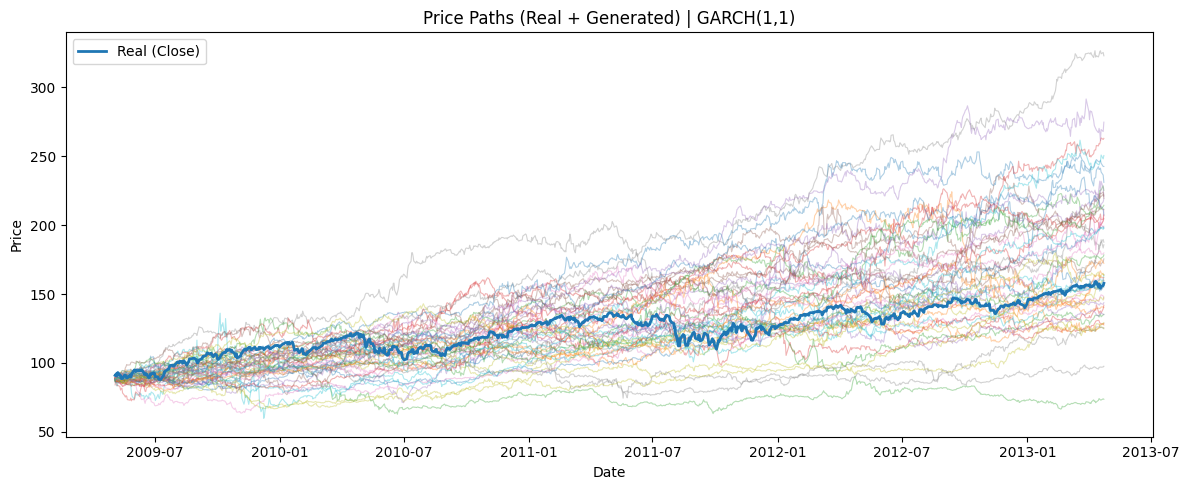

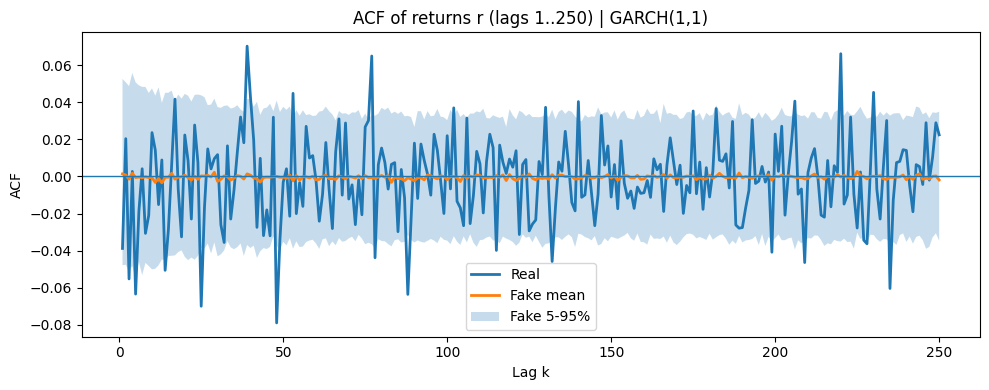

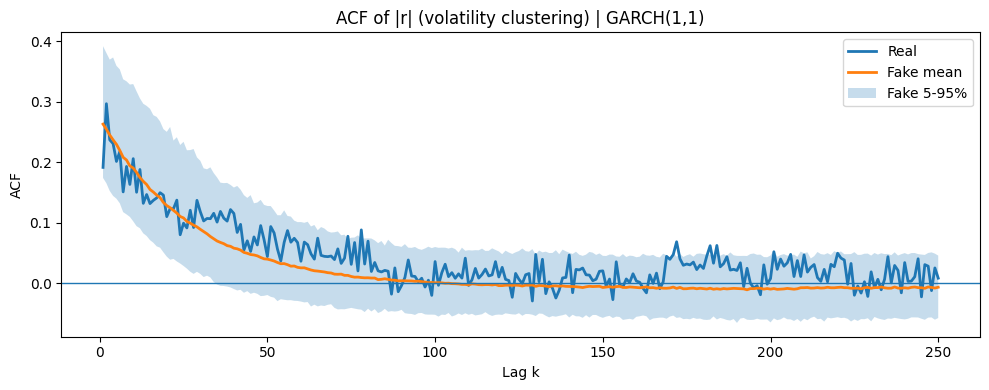

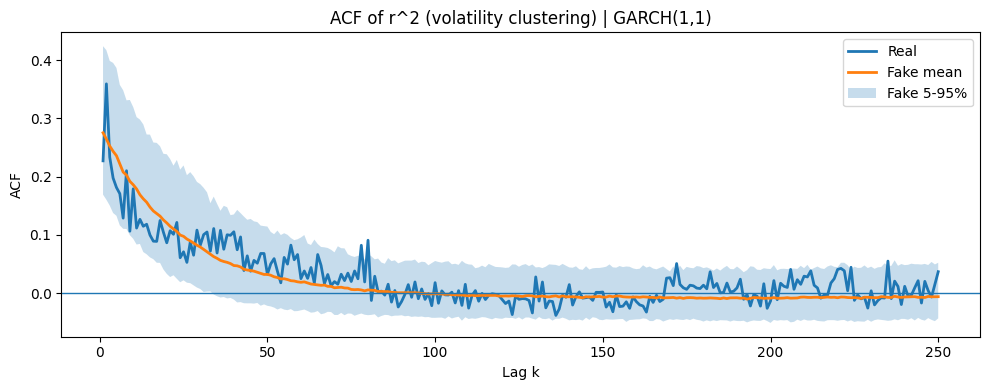

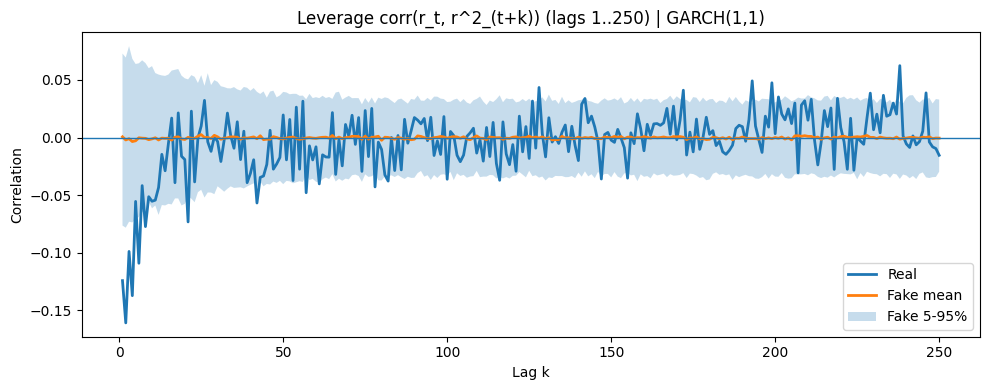

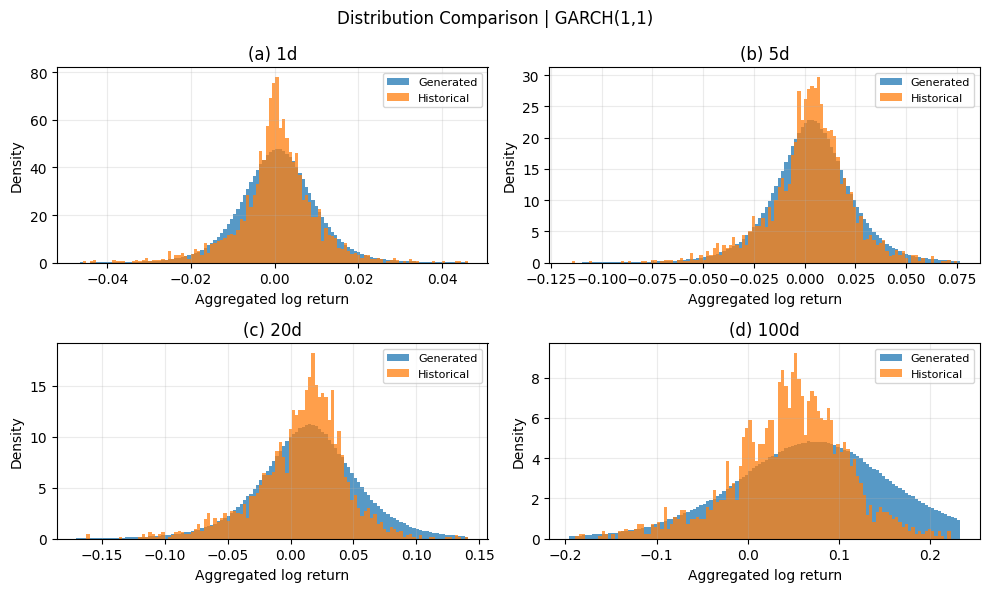

In [29]:
# GARCH plots

N9Y = 1000
plotter.plot_price_paths(
    close_series=close.iloc[:N9Y + 1],
    fake_logret_paths=fake_paths_garch[:, :N9Y],
    n_paths=50,
    title='Price Paths (Real + Generated) | GARCH(1,1)',
)

plotter.plot_acf_bundle(
    real_r=real_series,
    fake_paths=fake_for_plots_garch,
    S=S_lags,
    title_suffix=" | GARCH(1,1)",
)
plotter.plot_leverage(
    real_r=real_series,
    fake_paths=fake_for_plots_garch,
    S=S_lags,
    title_suffix=" | GARCH(1,1)",
)
plotter.plot_hist_panel(
    real_r=real_series,
    fake_paths=fake_for_plots_garch,
    t_lags=(1, 5, 20, 100),
    title="Distribution Comparison | GARCH(1,1)",
    label_fake="Generated",
    label_real="Historical",
)


In [30]:
# --- Save: GARCH(1,1) plots ---
N9Y = 1000
_ps = Plotter(show=False, save=True, out_dir=_DIRS['garch'])
_ps.plot_price_paths(
    close_series=close.iloc[:N9Y + 1],
    fake_logret_paths=fake_paths_garch[:, :N9Y],
    n_paths=50,
    title='Price Paths (Real + Generated) | GARCH(1,1)',
    filename='paths.pdf',
)
_ps.plot_acf_bundle(
    real_r=real_series,
    fake_paths=fake_for_plots_garch,
    S=S_lags,
    title_suffix=' | GARCH(1,1)',
    filename_prefix='acf',
)
_ps.plot_leverage(
    real_r=real_series,
    fake_paths=fake_for_plots_garch,
    S=S_lags,
    title_suffix=' | GARCH(1,1)',
    filename='leverage.pdf',
)
_ps.plot_hist_panel(
    real_r=real_series,
    fake_paths=fake_for_plots_garch,
    t_lags=(1, 5, 20, 100),
    title='Distribution Comparison | GARCH(1,1)',
    label_fake='Generated',
    label_real='Historical',
    filename='hist-2x2.pdf',
    clip_q=(0.001, 0.999),
)
print('Saved: garch_outputs/*.pdf')


Saved: garch_outputs/*.pdf


In [31]:
import pandas as pd
from scipy.stats import wasserstein_distance, kurtosis as scipy_kurtosis
from quantgan.evaluation.metrics import agg_returns_overlapping


try:
    from tabulate import tabulate

    def print_table(df, title):
        print("\n" + title)
        print(tabulate(df, headers="keys", tablefmt="github", showindex=True))
except Exception:
    def print_table(df, title):
        print("\n" + title)
        print(df.to_string())


# ------------------------------------------------------------
# collect results
# ------------------------------------------------------------
T_LAGS = (1, 5, 20, 100)

paper_score_garch, parts_garch = evaluator.paper_score(fake_paths_garch)

models = {
    "Pure TCN":   (fake_paths,       parts),
    "SVNN":       (fake_paths_svnn,  parts_svnn),
    "GARCH(1,1)": (fake_paths_garch, parts_garch),
}

rows = {}
for name, (paths, p) in models.items():
    flat = paths.reshape(-1)
    row = {
        "Mean":     float(flat.mean()),
        "Std":      float(flat.std()),
        "Kurtosis": float(scipy_kurtosis(flat, fisher=False, bias=False)),
        "ACF(r)":      p["acf_x"],
        "ACF(|r|)":    p["acf_abs"],
        "ACF(r²)":     p["acf_sq"],
        "Leverage":    p["lev"],
    }
    for t in T_LAGS:
        row[f"DY({t})"]  = p["dy_by_t"][t]
    rows[name] = row

# Historical row 
flat_real = np.asarray(real_series)
rows["Historical"] = {
    "Mean":     float(flat_real.mean()),
    "Std":      float(flat_real.std()),
    "Kurtosis": float(scipy_kurtosis(flat_real, fisher=False, bias=False)),
    **{f"DY({t})":  np.nan for t in T_LAGS},
    "ACF(r)": np.nan, "ACF(|r|)": np.nan, "ACF(r²)": np.nan, "Leverage": np.nan,
}

df = pd.DataFrame(rows).T
df = df.loc[["Historical", "Pure TCN", "SVNN", "GARCH(1,1)"]]

# ------------------------------------------------------------
# format for display
# ------------------------------------------------------------
fmt = {
    "Mean": "{:.6f}", "Std": "{:.6f}", "Kurtosis": "{:.3f}",
    **{f"DY({t})":  "{:.2f}" for t in T_LAGS},
    "ACF(r)": "{:.4f}", "ACF(|r|)": "{:.4f}", "ACF(r²)": "{:.4f}", "Leverage": "{:.4f}",
}

df_disp = df.copy()
for col, f in fmt.items():
    if col in df_disp.columns:
        df_disp[col] = df[col].apply(lambda x: f.format(x) if pd.notna(x) else "–")

# bold best (lowest) among models (exclude Historical) for metric cols
dist_cols = ["Mean", "Std", "Kurtosis"]
metric_cols = [c for c in df.columns if c not in dist_cols]
for col in metric_cols:
    vals = df.loc[["Pure TCN", "SVNN", "GARCH(1,1)"], col].astype(float)
    best = vals.idxmin()
    df_disp.loc[best, col] = f"**{df_disp.loc[best, col]}**"


dy_cols  = [f"DY({t})"  for t in T_LAGS]
dep_cols = ["ACF(r)", "ACF(|r|)", "ACF(r²)", "Leverage"]

print_table(df_disp[dist_cols], "1) Distribution (Mean / Std / Kurtosis)")
print_table(df_disp[dy_cols],   "2) DY")
print_table(df_disp[dep_cols],  "3) Dependence (ACF / Leverage)")



1) Distribution (Mean / Std / Kurtosis)
|            |     Mean |      Std |   Kurtosis |
|------------|----------|----------|------------|
| Historical | 0.00043  | 0.009623 |      6.975 |
| Pure TCN   | 0.000426 | 0.008961 |      8.308 |
| SVNN       | 0.000411 | 0.009071 |      7.566 |
| GARCH(1,1) | 0.000725 | 0.010067 |      8.783 |

2) DY
|            | DY(1)     | DY(5)     | DY(20)    | DY(100)   |
|------------|-----------|-----------|-----------|-----------|
| Historical | –         | –         | –         | –         |
| Pure TCN   | 18.59     | 16.71     | 20.03     | 35.49     |
| SVNN       | **18.05** | **14.95** | **17.54** | **23.57** |
| GARCH(1,1) | 27.21     | 19.84     | 28.04     | 40.90     |

3) Dependence (ACF / Leverage)
|            | ACF(r)     | ACF(|r|)   | ACF(r²)    | Leverage   |
|------------|------------|------------|------------|------------|
| Historical | –          | –          | –          | –          |
| Pure TCN   | **0.0227** | **0.0242** | 